# Bias-Variance Decomposition with Decision Trees and Bagging

This notebook explores the Bias-Variance Decomposition to show how Bagging effectively reduce model variance. For the experiment we will use an artificial dataset where we inject some gaussian noise, then we train different models like standard decision tree regressors and the bagging regressor. To conclude we discuss about the achieved results showing that bagging can reduce variance mitigating the problem of overfitting.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import BaggingRegressor
from sklearn.metrics import mean_squared_error
np.random.seed(42)

## Artificial Dataset

The synthetic data will be generated by applying a known function and incorporating Gaussian noise to simulate real-world variability.

Doing this we are defining a target function like the following $y=f(x)+ϵ$.
Then the goal for training is to find a function $g$ that can approximates the true function. Given the hypothesis $g$ the squared error can be decomposed as:
$$\mathbb{E}\left[(y-g(x))^2\right]=noise^2+bias^2+variance$$
where:

$\mathrm{Noise}^2:\mathbb{E}\left[(y-f(x))^2\right]$ (the noise is irreducible)

$\mathrm{Bias}^2:(\mathbb{E}[g(x)]-f(x))^2$

$\mathrm{Variance~:~}\mathbb{E}\left[(g(x)-\mathbb{E}[g(x)])^2\right]$

As we will show a good way to reduce variance (but possibly also reducing bias) is averaging multiple hypotheses.

In [ ]:
def f(X):
  return np.sin(X) # sine function will be the true function

n_samples = 100
X = np.linspace(-5, 5, n_samples).reshape(-1, 1)
y_true = f(X).reshape(-1)
y = y_true + np.random.normal(size=n_samples)  # add noise

X_plot = np.linspace(-5, 5, 500)[:, np.newaxis]

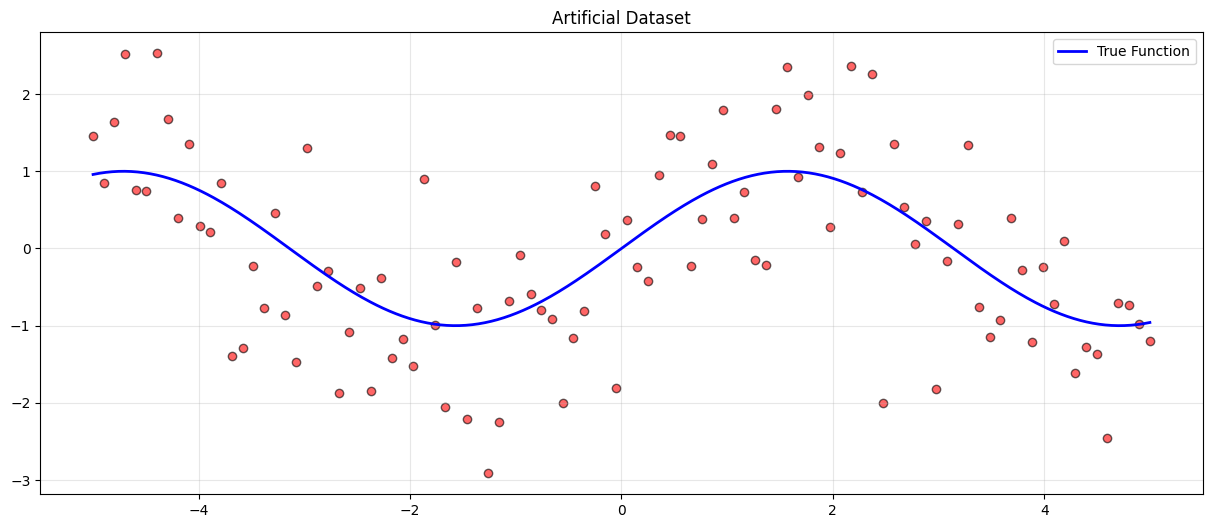

In [ ]:
plt.figure(figsize=(15, 6))
plt.title("Artificial Dataset")
plt.scatter(X, y, color="red", alpha=0.6, edgecolors='black')
plt.plot(X_plot, f(X_plot), color="blue", linewidth=2, label="True Function")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Training Decision Tree Regressors and Bagging Regressor

For this experiment we will use:  

1.   A Decision Tree Regressor with a ```max_depth=2``` that shouldn't be sufficient to capture the underlying relationships in data leading to underfitting (high bias).
2.   A Decision Tree Regressor with a ```max_depth=20``` that will likely overfit (high variance) because the tree will be very complex.
3.   A Bagging Regressor that is an ensemble meta-estimator that improves prediction accuracy and reduces variance by fitting multiple base regressors (like decision trees) on random subsets of the original training data, and then averaging (or voting on) their individual predictions to produce a more stable final prediction.

For the bagging regressor we will use on purpose the overfitting decision tree regressor as meta-estimator to see if it can reduce the instability of complex models by introducing randomization and combining their results.

In [ ]:
# More simple Decision Tree Regressor
simple_dt = DecisionTreeRegressor(max_depth=2)
simple_dt.fit(X, y)
simple_dt_mse = mean_squared_error(simple_dt.predict(X), y)
y_pred_simple_dt_plot = simple_dt.predict(X_plot)

# More complex Decision Tree Regressor
complex_dt = DecisionTreeRegressor(max_depth=20)
complex_dt.fit(X, y)
y_pred_complex_dt_plot = complex_dt.predict(X_plot)
complex_dt_mse = mean_squared_error(complex_dt.predict(X), y)

# Bagging Regressor
bagging_regressor = BaggingRegressor(
    estimator=DecisionTreeRegressor(max_depth=20),
    n_estimators=100,
    bootstrap=True, # Use bootstrap samples
    random_state=42,
)
bagging_regressor.fit(X, y)
y_pred_bagging = bagging_regressor.predict(X_plot)
bagging_mse = mean_squared_error(bagging_regressor.predict(X), y)

### Bootstrap sample
Our bagging regressor is using bootstrapping to try achieving independence of models, this is because bagging will not work if models are not independent enough.
So bootstrapping is defined as sample with replacement $M$ overlapping groups of
instances of the same size.

## Visualization and analysis

In [ ]:
def make_plot(y_pred_plot, title, regressor_label, regressor_linestyle, regressor_color):
  plt.figure(figsize=(15, 6))
  plt.title(title)
  plt.scatter(X, y, s=20, edgecolor="black", c="darkorange", label="Noisy Data")
  plt.plot(X_plot, np.sin(X_plot), color="blue", linewidth=2, label="True Function $\\sin(x)$")
  plt.plot(X_plot, y_pred_plot, color=regressor_color, linestyle=regressor_linestyle, linewidth=2, label=regressor_label)
  plt.xlabel("X")
  plt.ylabel("Y")
  plt.legend()
  plt.grid(True, alpha=0.3)
  plt.show()

As expected the decision tree regressor with only 2 level of depth is clearly underfitting, in fact it cannot capture the sine curve. The MSE is quite high in this case leading to high bias.

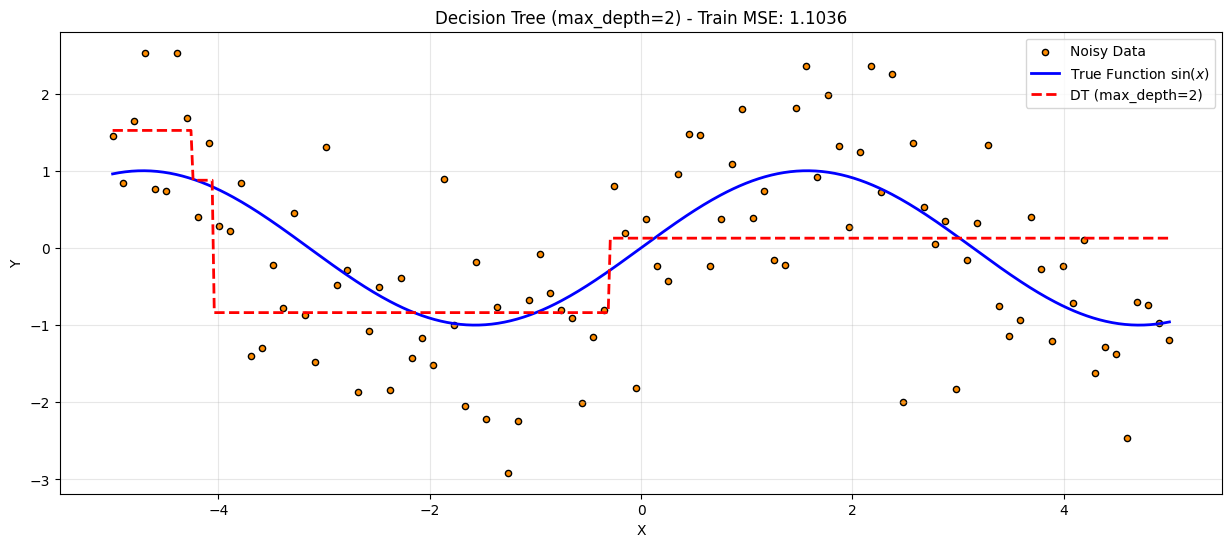

In [ ]:
make_plot(y_pred_simple_dt_plot, f"Decision Tree (max_depth=2) - Train MSE: {simple_dt_mse:.4f}", "DT (max_depth=2)", "--", "red")

The decision tree regressor with a max_depth equal to 20 is clearly overfitting (high variance). It is quite evident from the plot and also the train MSE is equal to zero so the model has perfectly memorized the training data, including its noise and random fluctuations, rather than learning the underlying function. So it is clear that this model will fail to generalize on new unseen examples drawn from the same data distribution.

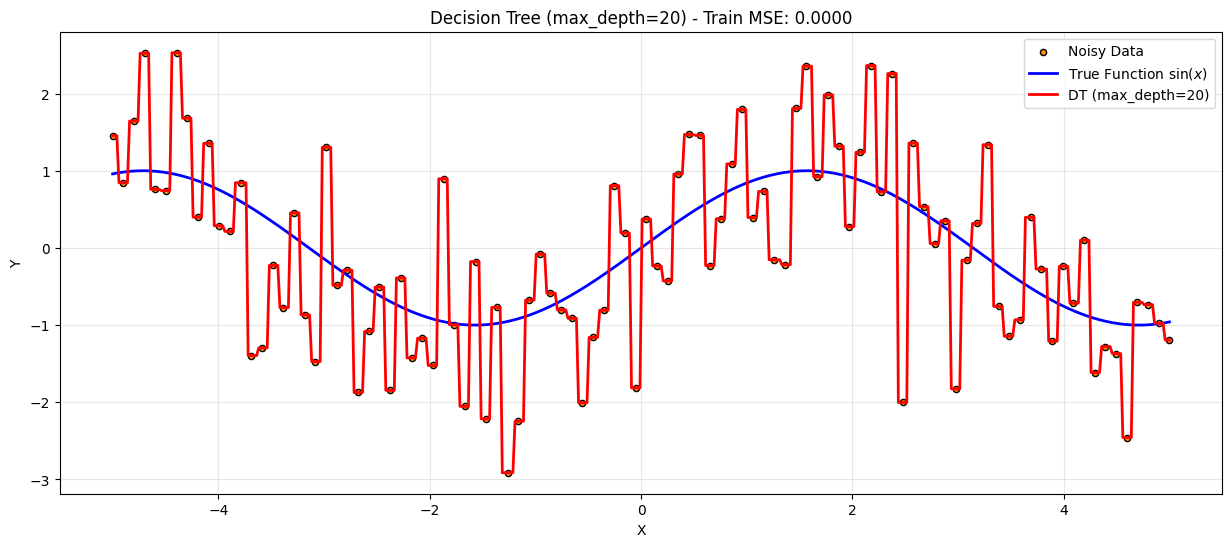

In [ ]:
make_plot(y_pred_complex_dt_plot, f"Decision Tree (max_depth=20) - Train MSE: {complex_dt_mse:.4f}", "DT (max_depth=20)", "-", "red")

For the bagging regressor we should say that as a meta-estimator we are using a decision tree with ```max_depth=20```. This is very important to remark, because with high chance every single regressor in the ensemble is overfitting. But since we are considering multiple hypotheses and averaging using all the individual predictions we can observe that our data are not overfitting as the model before. In fact, from the plot we can see a reduction in variance. The MSE remain relatively low if we think to the one that we had with the simple underfitting tree.

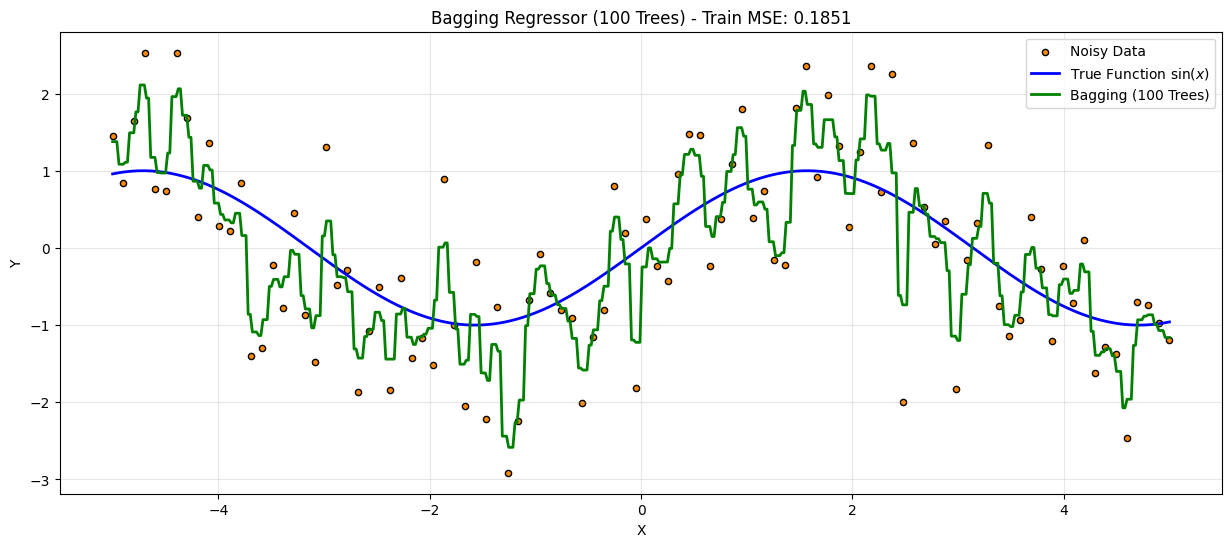

In [ ]:
make_plot(y_pred_bagging, f"Bagging Regressor (100 Trees) - Train MSE: {bagging_mse:.4f}", "Bagging (100 Trees)", "-", "green")

## Conclusion

We showed how Bagging helps with prediction errors.

A single, deep Decision Tree was too complicated and completely overfit the training data. This means it had high variance.

The Bagging Regressor used many of these overfitted trees, but by averaging their guesses, it smoothed out the extreme predictions. This reduced the overall variance of the model.

In short, Bagging is a great way to take unstable, complex models and make them more reliable so they work better on new data.

## Use of AI assistant
I used AI assistant to help me with english language in order to write better some sentences.

## References

Slide Lez13 - Practical Issues

Slide Lez17 - Ensemble Learning

https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeRegressor.html

https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.BaggingRegressor.html

